In [3]:
import tensorflow as tf                                  # Imports the Tensorflow library for building and training neural networks
from tensorflow import keras                             # Imports Keras API from Tensorflow
# Print installed version of the library
print(tf.__version__)
print(keras.__version__)
# Import all necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split     # For splitting dataset into train and test parts


2.19.0
3.10.0


In [4]:
df=pd.read_excel('Simpleio.xlsx')   # Reads uploaded Excel File
df                                  # Displays the loaded data in notebook
df = df.values                      # Converts Pandas DataFrame to NumPy array
xs = df[:, 0]                       # Select the first column → independent variable (X values)
ys = df[:, 1]                       # Select the second column → dependent variable (Y values)
print(df)                           # Prints the raw NumPy array values

[[ 0.04981121  5.3578233 ]
 [ 0.09962241  5.66317734]
 [ 0.1549682   5.99546497]
 [ 0.21031398  6.31947144]
 [ 0.26565976  6.63426069]
 [ 0.32100555  6.93891889]
 [ 0.38250086  7.2644727 ]
 [ 0.44399618  7.57527423]
 [ 0.51232431  7.90199367]
 [ 0.58065244  8.2078077 ]
 [ 0.65657258  8.52162186]
 [ 0.74092829  8.83659809]
 [ 0.83465687  9.14322459]
 [ 0.93879972  9.42886211]
 [ 1.06737115  9.70066606]
 [ 1.21022829  9.89952808]
 [ 1.36895845 10.        ]
 [ 1.5453253   9.97857467]
 [ 1.70405545  9.85892518]
 [ 1.8469126   9.68756286]
 [ 1.98976974  9.47221848]
 [ 2.13262688  9.22831793]
 [ 2.27548403  8.97008939]
 [ 2.41834117  8.70990975]
 [ 2.56119831  8.45788329]
 [ 2.70405545  8.22165847]
 [ 2.8469126   8.00646275]
 [ 2.98976974  7.81531662]
 [ 3.13262688  7.64937719]
 [ 3.27548403  7.50835948]
 [ 3.43421418  7.37932828]
 [ 3.59294434  7.27695668]
 [ 3.76931119  7.19120858]
 [ 3.94567803  7.13192415]
 [ 4.12204487  7.09718523]
 [ 4.29841172  7.08662899]
 [ 4.47477856  7.1014417 ]
 

In [5]:
#X_train=xs[0:70]
#X_test=xs[71::]
#Y_train=ys[0:70]
#Y_test=ys[71::]
#print(X_train)
#print(X_test)
#print(Y_train)
#print(Y_test)

In [6]:
X_train, X_test, Y_train, Y_test = train_test_split(xs, ys, test_size=0.3, random_state=0)
# Splits the dataset into training (70%) and testing (30%)
# random_state = 0 ensures reproducibility
print(X_test)   # Prints the test input values
print(Y_test)   # Prints the test target values

[0.1549682  3.43421418 7.02899444 1.36895845 0.93879972 6.73889514
 7.3616841  5.89100431 3.94567803 8.71622253 8.8099511  0.44399618
 7.09048975 7.62734386 5.58941701 7.25652711 0.51232431 2.27548403
 7.74418496 9.97628375 2.8469126  5.44655986 2.56119831 0.38250086
 5.30370272 7.94992855 8.13842712 7.31187289]
[ 5.99546497  7.37932828  5.89701021 10.          9.42886211  7.16170223
  3.99198465  8.1120287   7.13192415  0.44125718  0.72073056  7.57527423
  5.57210821  2.40560962  7.85436077  4.62499925  7.90199367  8.97008939
  1.76949993  4.91324005  8.00646275  7.7102248   8.45788329  7.2644727
  7.56987754  0.83451213  0.25639799  4.29365787]


In [7]:
# model = tf.keras.models.Sequential([tf.keras.layers.Dense(1,input_dim=1), tf.keras.layers.Dense(5,activation=tf.nn.sigmoid), tf.keras.layers.Dense(1)])
model = tf.keras.models.Sequential()                        # Creates an empty Sequential model (layer by layer)

model.add(tf.keras.layers.Dense(1, input_dim=1))            # First Dense layer with 1 neuron and input dimension = 1
model.add(tf.keras.layers.Dense(5, activation='sigmoid'))   # Hidden layer with 5 neurons using Sigmoid activation
model.add(tf.keras.layers.Dense(1))                         # Output layer with 1 neuron (regression output)


C:\Users\vivek\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [8]:
model.summary()          # Prints detailed architecture, parameters for each layer, and total trainable parameters

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 1)              │             2 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │            10 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             6 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18 (72.00 B)

 Trainable params: 18 (72.00 B)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.1),  # Optimizer = Adam, high learning rate = 0.1
    loss=tf.keras.losses.MeanSquaredError(),                # Loss function = MSE (good for regression)
    metrics=[tf.keras.metrics.MeanSquaredError()]           # Also track MSE as a metric while training
)

In [10]:
model.fit(X_train, Y_train, epochs=1000, verbose=1)   # Train for 1000 epochs with progress updates


Epoch 1/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 4s 39ms/step - loss: 45.6350 - mean_squared_error: 45.6350
Epoch 2/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step - loss: 32.5346 - mean_squared_error: 32.5346
Epoch 3/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 20.0359 - mean_squared_error: 20.0359
Epoch 4/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 103ms/step - loss: 15.2716 - mean_squared_error: 15.2716
Epoch 5/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 10.2364 - mean_squared_error: 10.2364 
Epoch 6/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - loss: 8.7993 - mean_squared_error: 8.7993
Epoch 7/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 8.2531 - mean_squared_error: 8.2531
Epoch 8/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step - loss: 9.5155 - mean_squared_error: 9.5155  
Epoch 9/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: 7.5574 - mean_squared_error: 7.5574
Epoch 10/1000
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 6.1622 - mean_squared_error: 6.1622
Epoch 11/1000
3/3 ━━━━━━━━━━━━━━━━━

In [11]:
model.evaluate(X_test, Y_test, verbose=2)
# Evaluates model performance on unseen test data
# Returns [loss_value, metric_value]


1/1 - 1s - 530ms/step - loss: 0.7606 - mean_squared_error: 0.7606


[0.7605950236320496, 0.7605950236320496]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 440ms/step


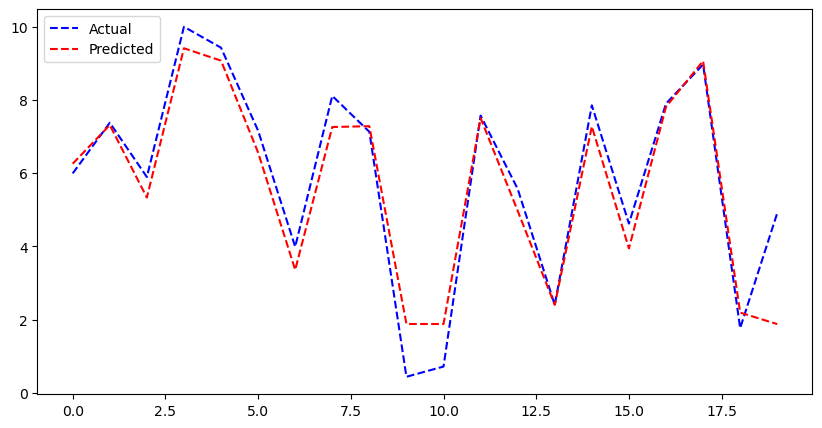

In [12]:
X_new = X_test[:20]                                                         # Select first 20 test samples as "new" data
y_pred = model.predict(X_new)                                               # Predict outputs for X_new using trained model
plt.figure(figsize=(10,5))
plt.plot(np.arange(0, len(X_new), 1), Y_test[:20], 'b--', label='Actual')   # Plot actual Y values
plt.plot(np.arange(0, len(X_new), 1), y_pred, 'r--', label='Predicted')     # Plot predicted Y values
plt.legend()
plt.show()



[0.88333683]


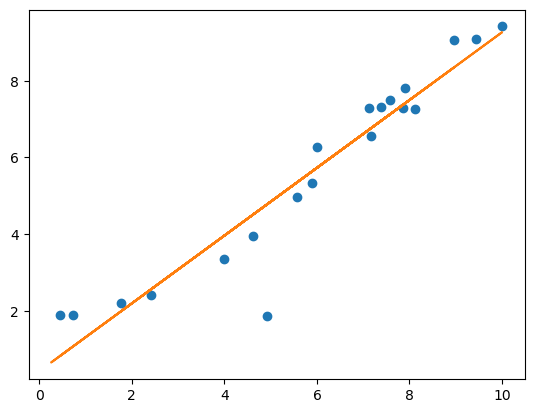

In [13]:
X_new = X_test[:20]
plt.plot(Y_test[:20], y_pred, 'o')             # Scatter plot of true Y vs predicted Y
m, b = np.polyfit(Y_test[:20], y_pred, 1)      # Fit a line y = mX + b to compare prediction trend
plt.plot(Y_test, m * Y_test + b)               # Plot line of best fit
print(m)                                       # Print slope of the line


In [14]:
#from sklearn.linear_model import LinearRegression
#x = xs
#y = ys
# create a linear regression model
#model = LinearRegression()
#model.fit(x, y)
# predict y from the data
#y_new = model.predict(X_new)